In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl

import src as scit
import matplotlib.pyplot as plt
import cv2

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('base_mean') > 0.5) & (pl.col('group') == 'Muscle'))
mt_muscle_acet = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('base_mean') > 0.8) & (pl.col('group') == 'Muscle'))

In [3]:
rna_acme_corr = pl.read_csv('private/data/rna_acme_corr.csv')

In [4]:
cttag_shape0 = 26324
q = 0.20#0.15658714481081903
ac_breadth = pl.read_csv('private/newest/acet_breadth.csv').filter(pl.col('breadth')>0.01*cttag_shape0)
me_breadth = pl.read_csv('private/newest/meth_breadth.csv').filter(pl.col('breadth')>0.01*cttag_shape0)

ac_broad = ac_breadth.filter(pl.col('breadth')>cttag_shape0*q)
me_broad = me_breadth.filter(pl.col('breadth')>cttag_shape0*q)
me_broad = me_broad['name'].to_numpy()
ac_broad = ac_broad['name'].to_numpy()
ac_narrow = ac_breadth.filter(pl.col('breadth')<cttag_shape0*q)
me_narrow = me_breadth.filter(pl.col('breadth')<cttag_shape0*q)
me_narrow = me_narrow['name'].to_numpy()
ac_narrow = ac_narrow['name'].to_numpy()
#me_breadth = pl.read_csv('private/data/meth_breadth.csv')

In [5]:
# for g in ac_broad:
#     print(g)

In [3]:
meth_change = pl.read_csv('private/meth_change.csv').sort('base_mean')#.filter(pl.col('name').is_in(active_meth))
acet_change = pl.read_csv('private/acet_change.csv').sort('base_mean')
meth_change = meth_change.filter(pl.col('group') != 'Fat Body',pl.col('base_mean')>0.6).sort('score')
acet_change = acet_change.filter(pl.col('group') != 'Fat Body',pl.col('base_mean')>0.7).sort('score')

In [4]:
ref = scit.ld.gtf('../data/dmel-all-r6.56.gtf', extra_key='gene_id')
obodag = scit.ld.obodag('../data/go-basic.obo')
ns2assoc = scit.ld.gaf('../data/fb.gaf', obodag, name_column=2)
#obodag = scit.ld.obodag('../data/dm-stage6.obo', namespaces = { 'insitu': 'MF' })
#ns2assoc = scit.ld.gaf('../data/stage6_gene2go.gaf', obodag)#, name_column=2)

../data/go-basic.obo: fmt(1.2) rel(2024-10-27) 44,017 Terms


In [8]:
meth_change

pval,score,base_mean,name,group
f64,f64,f64,str,str
0.011011,-3.725245,0.6884104,"""BuGZ""","""Midgut"""
0.000981,-3.465939,0.9664153,"""Hacd1""","""Muscle"""
0.069024,-3.176761,0.6099119,"""sxc""","""Midgut"""
0.006306,-2.951759,0.760274,"""Pcf11""","""Ventral Nerve Cord"""
0.049645,-2.867618,0.600587,"""Dph5""","""Muscle"""
…,…,…,…,…
8.5399e-21,2.1354797,2.0454314,"""CG10062""","""Midgut"""
8.5399e-21,2.1701694,2.791245,"""how""","""Midgut"""
0.008903,2.4159222,1.1904329,"""CG3106""","""Midgut"""


In [9]:
#meth_pop = mt_muscle_meth['name'].unique().to_numpy()
#acet_pop = mt_muscle_acet['name'].unique().to_numpy()
#pop = rna_acme_corr['var_name'].unique().to_numpy()
pop = meth_change['name'].unique().to_numpy()

res = scit.tl.goea(
    obodag,
    ns2assoc,
    scit.tl.symbol2id(ref, pop),
    scit.tl.symbol2id(ref, meth_change.filter(pl.col('base_mean')>0.6,pl.col('pval')<0.1,pl.col('score') > 0.2)['name'].unique().to_numpy()),
    #scit.tl.symbol2id(ref, rna_acme_corr.filter(pl.col('res') < 0.3).filter(pl.col('res_meth') > 0.2)['var_name'].to_numpy()),
    # mt_muscle_acet.filter((pl.col('pval')<0.01) & (pl.col('score') < -0.2))['name'].to_numpy()),
    propagate_counts=True,
    alpha=0.1
)


Load BP Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 81%  4,939 of  6,075 population items found in association

Load CC Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 81%  4,939 of  6,075 population items found in association

Load MF Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 81%  4,939 of  6,075 population items found in association

Runing BP Ontology Analysis: current study set of 1350 IDs.
 77%  1,044 of  1,350 study items found in association
100%  1,350 of  1,350 study items found in population(6075)
Calculating 5,800 uncorrected p-values using fisher_scipy_stats


KeyboardInterrupt: 

In [29]:
pl.DataFrame(res.df).write_csv('private/newest/goterm/meth_increasing.csv')

In [7]:
res=pl.read_csv('private/newest/goterm/meth_increasing.csv')

In [8]:
res.filter(pl.col('NS')=='BP').filter(pl.col('enriched')).sort('p_corrected')

NS,GO,name,depth,enriched,pop_count,study_count,p_corrected,p_uncorrected
str,str,str,i64,bool,i64,i64,f64,f64
"""BP""","""GO:0000122""","""negative regulation of transcr…",11,true,147,62,0.000091,5.1034e-8
"""BP""","""GO:0006355""","""regulation of DNA-templated tr…",9,true,598,187,0.000091,6.2983e-8
"""BP""","""GO:2001141""","""regulation of RNA biosynthetic…",8,true,598,187,0.000091,6.2983e-8
"""BP""","""GO:0006357""","""regulation of transcription by…",10,true,507,162,0.000155,1.3336e-7
"""BP""","""GO:0045892""","""negative regulation of DNA-tem…",10,true,198,72,0.002002,0.000005
…,…,…,…,…,…,…,…,…
"""BP""","""GO:0045944""","""positive regulation of transcr…",11,true,200,68,0.021943,0.000125
"""BP""","""GO:0030154""","""cell differentiation""",3,true,216,72,0.026267,0.000159
"""BP""","""GO:0007469""","""antennal development""",5,true,9,7,0.079834,0.000619


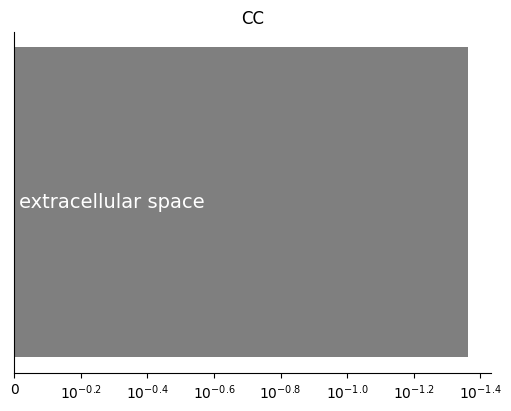

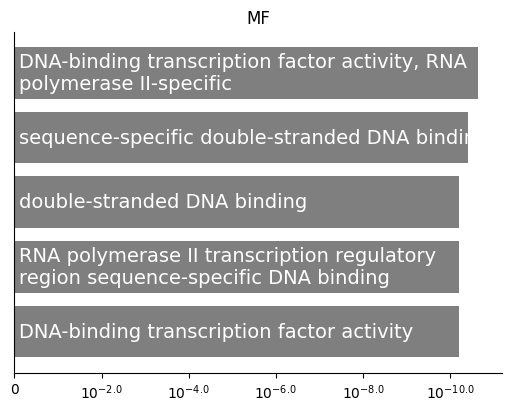

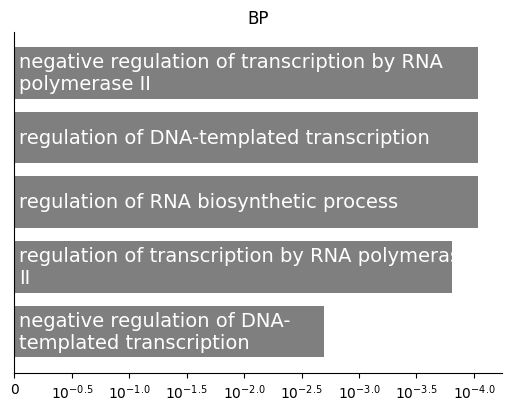

In [12]:
scit.set_defaults(figsize=(5,4))
scit.pl.goea(res, color='tab:gray', mode='enriched_only', n_top=5, plot_type='smart', text_size=14, wrap_width=50)

In [11]:
scit.pl.goea(res, 'simple')

AttributeError: 'DataFrame' object has no attribute 'df'

In [67]:
fs = scit.pl.goea(res, 'simple', show=False, n_top=40)
m = scit.adv.ImageToolsCV2.join_figures(fs, crop=False, direction='vertical') 

cv2.imwrite(f'private/newest/goterm/meth_down.png', m)
plt.close('all')

In [6]:
# combo_th = [
#     #acet ,      meth
#     ((-1, 0.3),  (0.2, 1)),
#     ((0.3, 1),   (0.2, 1)),
#     ((0.3, 1),  (-1, -0.4)),
#     ((-1, -0.4), (-1, -0.4)),
#     ((0.3, 1), (-0.4, 0.2)),
#     ((-1, -0.4), (-0.4, 0.2)),
#     ((-0.4, 0.3), (-1, 0.2))
# ]
combo_th = [
    #acet ,      meth
    ((-1, 0),  (0, 1)),
    ((-1, 0),   (-1, 0)),
    ((0, 1),  (0, 1)),
    ((0, 1), (-1, 0))
]
pop = rna_acme_corr['var_name'].unique().to_numpy()

ress = []
labels = []

for th in combo_th:
    ress.append(
        scit.tl.goea(
            obodag,
            ns2assoc,
            scit.tl.symbol2id(ref, pop),
            scit.tl.symbol2id(ref, rna_acme_corr.filter(pl.col('res') >= th[0][0]).filter(pl.col('res') <= th[0][1]).filter(pl.col('res_meth') >= th[1][0]).filter(pl.col('res_meth') <= th[1][1])['var_name'].to_numpy()),
            # mt_muscle_acet.filter((pl.col('pval')<0.01) & (pl.col('score') < -0.2))['name'].to_numpy()),
            propagate_counts=True,
            alpha=0.1
        )
    )
    labels.append(f"acet_{th[0][0]},{th[0][1]}__meth_{th[1][0]},{th[1][1]}")


Load BP Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 86%  3,823 of  4,433 population items found in association

Load CC Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 86%  3,823 of  4,433 population items found in association

Load MF Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 86%  3,823 of  4,433 population items found in association

Runing BP Ontology Analysis: current study set of 426 IDs.
 88%    377 of    426 study items found in association
100%    426 of    426 study items found in population(4433)
Calculating 5,549 uncorrected p-values using fisher_scipy_stats
   5,549 terms are associated with  3,499 of  4,433 population items
   2,316 terms are associated with    343 of    426 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.1=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with si

In [ ]:
for label, res in list(zip(labels, ress)):
    fs = scit.pl.goea(res, 'simple', show=False, n_top=40)
    m = scit.adv.ImageToolsCV2.join_figures(fs, crop=False, direction='vertical') 

    cv2.imwrite(f'private/newest/goterm/Q{label}.png', m)
    plt.close('all')

ValueError: max() iterable argument is empty

In [24]:
gs = meth_change['group'].unique().to_numpy()

ress = {}

for g in gs:
    pop = meth_change.filter(pl.col('group')==g)['name'].to_numpy()
    ress[g] = scit.tl.goea(
        obodag,
        ns2assoc,
        scit.tl.symbol2id(ref, pop),
        scit.tl.symbol2id(ref, meth_change.filter(pl.col('base_mean')>0.6,pl.col('group')==g,pl.col('pval')<0.1,pl.col('score')>0.2)['name'].to_numpy()),
        propagate_counts=True,
        alpha=0.1
    )


Load BP Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 80%  2,860 of  3,575 population items found in association

Load CC Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 80%  2,860 of  3,575 population items found in association

Load MF Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 80%  2,860 of  3,575 population items found in association

Runing BP Ontology Analysis: current study set of 316 IDs.
 73%    232 of    316 study items found in association
100%    316 of    316 study items found in population(3575)
Calculating 4,984 uncorrected p-values using fisher_scipy_stats
   4,984 terms are associated with  2,607 of  3,575 population items
   1,433 terms are associated with    208 of    316 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.1=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with si

In [25]:
for label, res in ress.items():
    if len(res.df) == 0:
        continue
    # fs = scit.pl.goea(res, 'simple', show=False, n_top=40)
    # m = scit.adv.ImageToolsCV2.join_figures(fs, crop=False, direction='vertical') 
    _path = f'private/newest/goterm/meth_up_{label}'
    pl.DataFrame(res.df).write_csv(f'{_path}.csv')
    # cv2.imwrite(, m)
    plt.close('all')